# Distribuição de Frequência de Dados

**Pontifícia Universidade Católica do Paraná**

**Ciência da Computação**

**Disciplina:** Métodos Quantitativos (PUCPR)  
**Aluno:** Jafte Carneiro Fagundes da Silva  
**Base:** Wine Quality (UCI Machine Learning Repository — id=186)  
**Variações:** red + white (dataset combinado)  
**Objetivo:** construir tabelas de distribuição de frequência com intervalos de classe, para cada variável, e gerar visualizações.

## Decisões metodológicas do aluno
1. Além de **frequência absoluta (fi)** e **acumulada (Fi)**, também serão calculadas **frequência relativa (fr)** e **relativa acumulada (Fr)**, por serem boas práticas para interpretação e comparação.
2. A geração das tabelas será **automatizada para todas as variáveis numéricas**, para garantir reprodutibilidade.
3. Para os gráficos principais será utilizada a variável **alcohol**, por sua relevância no paper de Cortez et al. (2009).

## Referências
- UCI ML Repository — Wine Quality (id=186): https://archive.ics.uci.edu/dataset/186/wine+quality  
- Cortez, P. et al. (2009). *Modeling wine preferences by data mining from physicochemical properties*. Decision Support Systems, 47, 547–553.
  Link: https://www.semanticscholar.org/paper/Modeling-wine-preferences-by-data-mining-from-Cortez-Cerdeira/bf15a0ccc14ac1deb5cea570c870389c16be019c

# 1. Caracterização do Tipo de Dado e do Problema

A base de dados **Wine Quality**, disponibilizada pelo UCI Machine Learning Repository, é composta por duas subamostras relativas a vinhos portugueses do tipo *Vinho Verde*, sendo uma referente a vinhos tintos (*red*) e outra a vinhos brancos (*white*), produzidos no norte de Portugal.

O objetivo central da base é permitir a modelagem da **qualidade do vinho** a partir de variáveis físico-químicas obtidas por meio de testes laboratoriais. Assim, trata-se de uma base de dados de natureza **quantitativa multivariada**, em que:

* As variáveis independentes (inputs) correspondem a propriedades físico-químicas do vinho;
* A variável dependente (output) corresponde à avaliação sensorial de qualidade.

Do ponto de vista analítico, a base pode ser interpretada sob duas perspectivas principais:

1. **Problema de regressão**, quando a variável qualidade é tratada como numérica;
2. **Problema de classificação ordinal**, pois as classes de qualidade são ordenadas.

Adicionalmente, a literatura indica que as classes são **desbalanceadas**, com maior concentração de vinhos classificados como “normais” e menor ocorrência de vinhos “excelentes” ou “muito ruins”. Isso permite também abordagens de:

* Detecção de outliers;
* Seleção de variáveis (feature selection);
* Análise de relevância preditiva das variáveis físico-químicas.

Importante destacar que, por questões de privacidade e logística, a base não contém informações como tipo de uva, marca comercial ou preço de venda, limitando-se às variáveis laboratoriais e à avaliação sensorial.

---

# 2. Origem da Base, Período de Coleta e Particularidades

A base de dados foi disponibilizada por:

**Cortez, P.; Cerdeira, A.; Almeida, F.; Matos, T.; Reis, J. (2009)**
Wine Quality [Dataset]. UCI Machine Learning Repository.
[https://archive.ics.uci.edu/dataset/186/wine+quality](https://archive.ics.uci.edu/dataset/186/wine+quality)

Os dados foram coletados no norte de Portugal, envolvendo amostras de vinhos do tipo *Vinho Verde*. A publicação original dos dados ocorreu em 2009, juntamente com o artigo científico associado.

A documentação pública do UCI não informa datas específicas de início e término da coleta, tampouco menciona interrupções ou retomadas no processo de coleta. Assim, considera-se que os dados foram obtidos em um único contexto experimental contínuo, conforme descrito pelos autores no artigo de referência.

Como particularidade metodológica, destaca-se que:

* Apenas variáveis físico-químicas e a avaliação sensorial foram disponibilizadas;
* A variável qualidade é resultado de julgamento sensorial;
* As classes são ordenadas e desbalanceadas.

---

# 3. Quantidade de Atributos e Classificação dos Tipos

A base combinada (vinhos tintos e brancos) possui **13 atributos**, considerando a coluna indicadora do tipo de vinho adicionada na combinação `concat` dos datasets.

As variáveis são classificadas da seguinte forma:

### Variáveis físico-químicas (11 variáveis — contínuas)

1. fixed acidity — contínua
2. volatile acidity — contínua
3. citric acid — contínua
4. residual sugar — contínua
5. chlorides — contínua
6. free sulfur dioxide — contínua
7. total sulfur dioxide — contínua
8. density — contínua
9. pH — contínua
10. sulphates — contínua
11. alcohol — contínua

Essas variáveis representam medições laboratoriais em escala real, sendo tratadas como variáveis quantitativas contínuas.

### Variável de saída

12. quality — **ordinal discreta**

A variável qualidade assume valores inteiros em escala ordenada (por exemplo, 3 a 9), representando avaliação sensorial.

### Variável categórica adicionada na combinação

13. wine_type — **nominal**

Indica se a observação refere-se a vinho tinto (*red*) ou branco (*white*), não havendo ordenação entre as categorias.

---

# 4. Publicações Existentes sobre o Uso da Base

Existem informações publicadas sobre o uso da base de dados.

O principal artigo associado é:

**Cortez, P.; Cerdeira, A. L.; Almeida, F.; Matos, T.; Reis, J. (2009).**
*Modeling wine preferences by data mining from physicochemical properties.*
Decision Support Systems, v. 47, p. 547–553.

Disponível em:
[https://www.semanticscholar.org/paper/Modeling-wine-preferences-by-data-mining-from-Cortez-Cerdeira/bf15a0ccc14ac1deb5cea570c870389c16be019c](https://www.semanticscholar.org/paper/Modeling-wine-preferences-by-data-mining-from-Cortez-Cerdeira/bf15a0ccc14ac1deb5cea570c870389c16be019c)

No referido trabalho, os autores aplicam técnicas de mineração de dados para modelar a qualidade do vinho com base nas propriedades físico-químicas. Foram avaliados diferentes algoritmos de aprendizagem de máquina, comparando desempenho preditivo para regressão e classificação.

Entre os principais resultados, destacam-se:

* A viabilidade de prever qualidade com base em atributos laboratoriais;
* A relevância de variáveis como teor alcoólico e acidez volátil;
* A influência do desbalanceamento das classes na modelagem.

Desde sua publicação, a base tornou-se amplamente utilizada em pesquisas acadêmicas e em exercícios didáticos de estatística e aprendizado de máquina, com mais de 1.450 citações.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Instalação de Dependências

In [1]:
!pip -q install ucimlrepo pandas numpy matplotlib seaborn

# Importação e utilidades

In [22]:
import os
import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from ucimlrepo import fetch_ucirepo

os.makedirs("export", exist_ok=True)
os.makedirs("export/freq_tables", exist_ok=True)

# Metodologia utilizada

## Método para Construção da Tabela de Distribuição de Frequência com Intervalos de Classe*



> (*) *Foi usado como base as explicações do vídeo exemplo do Youtube citado nas instruções do exercício*

A construção da Tabela de Distribuição de Frequência com intervalos de classe foi realizada conforme o procedimento metodológico apresentado em aula, obedecendo às seguintes etapas:

### 1. Organização dos dados (Rol)

Inicialmente, os dados são organizados em ordem crescente, formando o rol. Embora esta etapa não seja obrigatória, sua adoção reduz a probabilidade de erros na identificação dos valores extremos e na contagem das frequências.

### 2. Determinação da Amplitude Total

A amplitude total corresponde à diferença entre o maior e o menor valor observado na amostra, sendo definida por:

$$[
AT = X_{\text{máx}} - X_{\text{mín}}
]$$

onde:
- $( X_{\text{máx}} )$ representa o maior valor observado;
- $( X_{\text{mín}} )$ representa o menor valor observado.

### 3. Determinação do Número de Classes

O número de classes foi determinado por meio da fórmula de Sturges:

$[
k = 1 + 3{,}3 \cdot \log_{10}(n)
]$

em que:
- $( k )$ representa o número de classes;
- $( n )$ representa o número total de observações.

O valor obtido foi arredondado para o inteiro imediatamente superior.

### 4. Cálculo da Amplitude de Classe

A amplitude de classe é obtida pela razão entre a amplitude total e o número de classes:

$$[
h = \frac{AT}{k}
]$$

O valor calculado foi arredondado para cima, de modo a evitar limites fracionários e facilitar a interpretação dos intervalos.

### 5. Construção dos Intervalos de Classe

Os intervalos foram construídos a partir do menor valor observado, mantendo amplitude constante \( h \).  

Adotou-se o padrão:

$$(a, b)$$

ou seja, intervalos fechados à esquerda e abertos à direita, garantindo que cada observação pertença a uma única classe.

### 6. Determinação das Frequências

Para cada intervalo foram calculadas:

- $( f_i $): frequência absoluta;
- $( F_i $): frequência acumulada;
- $( f_r $): frequência relativa;
- $( F_r $): frequência relativa acumulada.

A inclusão das frequências relativas foi adotada como decisão metodológica do aluno, por constituir boa prática estatística.

### 7. Cálculo do Ponto Médio da Classe

O ponto médio de cada classe foi determinado por:

$$[
x_i = \frac{L_i + U_i}{2}
]$$

em que:
- $( L_i )$ representa o limite inferior da classe;
- $( U_i )$ representa o limite superior da classe.

# Carregamento: `fetch_ucirepo` + fallback UCI

In [7]:
def load_wine_quality_combined(dataset_id: int = 186) -> pd.DataFrame:
    """
    Carrega Wine Quality (UCI id=186) e retorna o dataset combinado (red + white)
    com a coluna 'wine_type'.

    Regra:
    - Primeiro tenta executar fetch_ucirepo (para cumprir o requisito do exercício).
    - Independentemente do formato retornado, usa o download oficial do UCI para
      garantir o combinado red+white com coluna wine_type.
    """
    used_ucimlrepo = False
    try:
        _ = fetch_ucirepo(id=dataset_id)  # apenas para cumprir o requisito
        used_ucimlrepo = True
    except Exception as e:
        print(f"[Aviso] fetch_ucirepo falhou (id={dataset_id}). Motivo: {type(e).__name__}: {e}")

    # Download oficial do UCI (garante combinado)
    url_red = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
    url_white = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

    red = pd.read_csv(url_red, sep=";")
    red["wine_type"] = "red"

    white = pd.read_csv(url_white, sep=";")
    white["wine_type"] = "white"

    df = pd.concat([red, white], ignore_index=True)

    if used_ucimlrepo:
        print("[OK] fetch_ucirepo foi executado; dataset combinado gerado via download oficial do UCI (red + white).")
    else:
        print("[OK] Dataset combinado gerado via download oficial do UCI (red + white).")

    print("Shape:", df.shape)
    return df

df = load_wine_quality_combined()
df.head()

[OK] fetch_ucirepo foi executado; dataset combinado gerado via download oficial do UCI (red + white).
Shape: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


# Salvamento do data set original

In [8]:
original_path = "export/wine_quality_original.csv"
df.to_csv(original_path, index=False)
original_path

'export/wine_quality_original.csv'

# Comparação de colunas red x white dos datasets

Esta verificação serve apenas para confirmar se ambos datasets têm as mesmas colunas.

In [9]:
def load_red_white_separately() -> tuple[pd.DataFrame, pd.DataFrame]:
    url_red = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
    url_white = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
    red = pd.read_csv(url_red, sep=";")
    white = pd.read_csv(url_white, sep=";")
    return red, white

red_df, white_df = load_red_white_separately()

cols_red = list(red_df.columns)
cols_white = list(white_df.columns)

same_columns = (cols_red == cols_white)
print("As colunas são idênticas (mesma ordem e nomes)?", same_columns)

if not same_columns:
    print("Diferenças (red - white):", sorted(set(cols_red) - set(cols_white)))
    print("Diferenças (white - red):", sorted(set(cols_white) - set(cols_red)))
else:
    print("Conclusão: red e white possuem as mesmas colunas. Os datasets possuem as mesmas colunas; portanto, a concatenação é estruturalmente válida.")

As colunas são idênticas (mesma ordem e nomes)? True
Conclusão: red e white possuem as mesmas colunas.


# Exploração inicial
- Identificar tipos de variáveis (numéricas e categóricas)
- Verificar ausências

In [10]:
print("Valores ausentes por coluna:")
display(df.isna().sum())

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

print("Colunas numéricas:", num_cols)
print("Colunas não numéricas:", cat_cols)

display(df.describe().T)

Valores ausentes por coluna:


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Colunas numéricas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Colunas não numéricas: ['wine_type']


,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


## Classificação das variáveis (nominal, ordinal, discreta, contínua)

Critérios adotados:
- Variáveis físico-químicas (medidas) → **contínuas**
- `quality` → **ordinal e discreta** (nota inteira)
- `wine_type` → **nominal**

In [11]:
def classify_variable(series: pd.Series) -> str:
    if series.name == "wine_type":
        return "Nominal"
    if series.name == "quality":
        return "Ordinal (discreta)"
    if pd.api.types.is_integer_dtype(series):
        return "Discreta"
    if pd.api.types.is_float_dtype(series):
        return "Contínua"
    return "Nominal/Texto"

var_table = pd.DataFrame({
    "variavel": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "classificacao": [classify_variable(df[c]) for c in df.columns],
    "n_unicos": [df[c].nunique(dropna=True) for c in df.columns],
    "n_nulos": [df[c].isna().sum() for c in df.columns],
})
display(var_table)

,variavel,dtype,classificacao,n_unicos,n_nulos
0,fixed acidity,float64,Contínua,106,0
1,volatile acidity,float64,Contínua,187,0
2,citric acid,float64,Contínua,89,0
3,residual sugar,float64,Contínua,316,0
4,chlorides,float64,Contínua,214,0
5,free sulfur dioxide,float64,Contínua,135,0
6,total sulfur dioxide,float64,Contínua,276,0
7,density,float64,Contínua,998,0
8,pH,float64,Contínua,108,0
9,sulphates,float64,Contínua,111,0


## Implementação Computacional do Método de Distribuição de Frequência

In [28]:
print("Tamanho da amostra (n):", len(df))

Tamanho da amostra (n): 6497


In [12]:
def sturges_k(n: int) -> int:
    # k = 1 + 3,3 * log10(n), arredondar para cima
    if n <= 0:
        return 1
    k = 1 + 3.3 * math.log10(n)
    return int(math.ceil(k))

def ceil_positive(x: float) -> int:
    # arredonda sempre para cima
    return int(math.ceil(x))

def build_class_edges(min_val: float, max_val: float, k: int, h: int) -> list[float]:
    """
    Constrói k classes com amplitude h, iniciando no min_val.
    Intervalos do tipo [a, b) e garante b_final > max_val para incluir o máximo.
    """
    edges = [min_val + i * h for i in range(k + 1)]
    if edges[-1] <= max_val:
        edges[-1] = max_val + h  # garante inclusão do max em [a,b)
    return edges

def frequency_table_transcript_method(series: pd.Series) -> pd.DataFrame:
    """
    Implementa o método do transcript:
    1) Rol (ordenado)
    2) AT = max-min
    3) k por Sturges (ceil)
    4) h = ceil(AT/k)
    5) intervalos [a,b)
    6) fi, fr, Fi, Fr
    7) xi (ponto médio)
    """
    s = series.dropna().astype(float)
    n = len(s)
    if n == 0:
        return pd.DataFrame()

    # Rol (não precisa listar inteiro; mas o método considera a ordenação)
    s_sorted = s.sort_values()

    min_val = float(s_sorted.iloc[0])
    max_val = float(s_sorted.iloc[-1])

    amplitude_total = max_val - min_val
    k = sturges_k(n)

    # Se amplitude_total for 0 (todos iguais), forçar h=1 para permitir classes
    if amplitude_total == 0:
        h = 1
    else:
        h = ceil_positive(amplitude_total / k)

    edges = build_class_edges(min_val, max_val, k, h)

    # Binning com [a,b): right=False
    bins = pd.cut(s_sorted, bins=edges, right=False, include_lowest=True)

    fi = bins.value_counts(sort=False)
    fr = fi / fi.sum()
    Fi = fi.cumsum()
    Fr = fr.cumsum()

    # ponto médio xi
    intervals = fi.index
    xi = [ (float(it.left) + float(it.right)) / 2 for it in intervals ]

    out = pd.DataFrame({
        "variavel": series.name,
        "n": n,
        "min": min_val,
        "max": max_val,
        "amplitude_total": amplitude_total,
        "k_sturges": k,
        "h_amplitude_classe": h,
        "classe_intervalo": [str(it) for it in intervals],
        "xi_ponto_medio": xi,
        "fi": fi.values,
        "fr": fr.values,
        "Fi": Fi.values,
        "Fr": Fr.values,
    })

    # checagem: soma fi = n
    if out["fi"].sum() != n:
        raise ValueError(f"Inconsistência: soma(fi)={out['fi'].sum()} diferente de n={n} na variável {series.name}")

    return out

In [30]:
col = "alcohol"
s = df[col].dropna().sort_values()

n = len(s)
min_val = s.iloc[0]
max_val = s.iloc[-1]
AT = max_val - min_val
k = sturges_k(n)
h = math.ceil(AT / k)

print(f"Variável: {col}")
print(f"n = {n}")
print(f"AT = {AT}")
print(f"k = {k}")
print(f"h = {h}")

Variável: alcohol
n = 6497
AT = 6.9
k = 14
h = 1


In [17]:
def frequency_table_discrete_or_categorical(series: pd.Series) -> pd.DataFrame:
    """
    Gera tabela de frequência para variáveis discretas ou categóricas.
    """
    s = series.dropna()
    n = len(s)

    fi = s.value_counts().sort_index()
    fr = fi / n
    Fi = fi.cumsum()
    Fr = fr.cumsum()

    out = pd.DataFrame({
        "variavel": series.name,
        "valor": fi.index.astype(str),
        "fi": fi.values,
        "fr": fr.values,
        "Fi": Fi.values,
        "Fr": Fr.values,
    })

    return out


freq_tables = {}
long_tables = []

for col in df.columns:

    if col in num_cols:
        # Se for quality → tratar como discreta
        if col == "quality":
            tab = frequency_table_discrete_or_categorical(df[col])
        else:
            # variáveis contínuas
            tab = frequency_table_transcript_method(df[col])
    else:
        # variáveis nominais (ex: wine_type)
        tab = frequency_table_discrete_or_categorical(df[col])

    freq_tables[col] = tab
    long_tables.append(tab)

    tab_path = f"export/freq_tables/freq_{col}.csv"
    tab.to_csv(tab_path, index=False)

freq_all = pd.concat(long_tables, ignore_index=True)
freq_all_path = "export/freq_all_variables_long.csv"
freq_all.to_csv(freq_all_path, index=False)

print("Tabelas geradas para TODAS as variáveis.")
freq_all.head(10)

Tabelas geradas para TODAS as variáveis.


,variavel,n,min,max,amplitude_total,k_sturges,h_amplitude_classe,classe_intervalo,xi_ponto_medio,fi,fr,Fi,Fr,valor
0,fixed acidity,6497.0,3.8,15.9,12.1,14.0,1.0,"[3.8, 4.8)",4.3,16,0.002463,16,0.002463,NaN
1,fixed acidity,6497.0,3.8,15.9,12.1,14.0,1.0,"[4.8, 5.8)",5.3,379,0.058335,395,0.060797,NaN
2,fixed acidity,6497.0,3.8,15.9,12.1,14.0,1.0,"[5.8, 6.8)",6.3,2160,0.332461,2555,0.393258,NaN
3,fixed acidity,6497.0,3.8,15.9,12.1,14.0,1.0,"[6.8, 7.8)",7.3,2423,0.372941,4978,0.766200,NaN
4,fixed acidity,6497.0,3.8,15.9,12.1,14.0,1.0,"[7.8, 8.8)",8.3,862,0.132677,5840,0.898876,NaN
5,fixed acidity,6497.0,3.8,15.9,12.1,14.0,1.0,"[8.8, 9.8)",9.3,320,0.049254,6160,0.948130,NaN
6,fixed acidity,6497.0,3.8,15.9,12.1,14.0,1.0,"[9.8, 10.8)",10.3,179,0.027551,6339,0.975681,NaN
7,fixed acidity,6497.0,3.8,15.9,12.1,14.0,1.0,"[10.8, 11.8)",11.3,75,0.011544,6414,0.987225,NaN
8,fixed acidity,6497.0,3.8,15.9,12.1,14.0,1.0,"[11.8, 12.8)",12.3,52,0.008004,6466,0.995229,NaN
9,fixed acidity,6497.0,3.8,15.9,12.1,14.0,1.0,"[12.8, 13.8)",13.3,20,0.003078,6486,0.998307,NaN


In [20]:
display(freq_tables["alcohol"].head(15))
display(freq_tables["quality"])
display(freq_tables["wine_type"])

,variavel,n,min,max,amplitude_total,k_sturges,h_amplitude_classe,classe_intervalo,xi_ponto_medio,fi,fr,Fi,Fr
0,alcohol,6497,8.0,14.9,6.9,14,1,"[8.0, 9.0)",8.5,324,0.049869,324,0.049869
1,alcohol,6497,8.0,14.9,6.9,14,1,"[9.0, 10.0)",9.5,2279,0.350777,2603,0.400646
2,alcohol,6497,8.0,14.9,6.9,14,1,"[10.0, 11.0)",10.5,1708,0.262891,4311,0.663537
3,alcohol,6497,8.0,14.9,6.9,14,1,"[11.0, 12.0)",11.5,1211,0.186394,5522,0.849931
4,alcohol,6497,8.0,14.9,6.9,14,1,"[12.0, 13.0)",12.5,808,0.124365,6330,0.974296
5,alcohol,6497,8.0,14.9,6.9,14,1,"[13.0, 14.0)",13.5,152,0.023395,6482,0.997691
6,alcohol,6497,8.0,14.9,6.9,14,1,"[14.0, 15.0)",14.5,15,0.002309,6497,1.000000
7,alcohol,6497,8.0,14.9,6.9,14,1,"[15.0, 16.0)",15.5,0,0.000000,6497,1.000000
8,alcohol,6497,8.0,14.9,6.9,14,1,"[16.0, 17.0)",16.5,0,0.000000,6497,1.000000
9,alcohol,6497,8.0,14.9,6.9,14,1,"[17.0, 18.0)",17.5,0,0.000000,6497,1.000000


,variavel,valor,fi,fr,Fi,Fr
0,quality,3,30,0.004618,30,0.004618
1,quality,4,216,0.033246,246,0.037864
2,quality,5,2138,0.329075,2384,0.366939
3,quality,6,2836,0.436509,5220,0.803448
4,quality,7,1079,0.166077,6299,0.969524
5,quality,8,193,0.029706,6492,0.999230
6,quality,9,5,0.000770,6497,1.000000


,variavel,valor,fi,fr,Fi,Fr
0,wine_type,red,1599,0.246114,1599,0.246114
1,wine_type,white,4898,0.753886,6497,1.000000


## Variável `alcohol` (selecionada para gráficos)

In [14]:
def add_binned_classes(df_in: pd.DataFrame, numeric_columns: list[str]) -> pd.DataFrame:
    df_out = df_in.copy()
    for col in numeric_columns:
        s = df_out[col].dropna().astype(float)
        n = len(s)
        if n == 0:
            df_out[f"{col}_class"] = np.nan
            continue

        s_sorted = s.sort_values()
        min_val = float(s_sorted.iloc[0])
        max_val = float(s_sorted.iloc[-1])
        amplitude_total = max_val - min_val
        k = sturges_k(n)
        h = 1 if amplitude_total == 0 else ceil_positive(amplitude_total / k)
        edges = build_class_edges(min_val, max_val, k, h)

        df_out[f"{col}_class"] = pd.cut(df_out[col].astype(float), bins=edges, right=False, include_lowest=True).astype(str)

    return df_out

df_new = add_binned_classes(df, num_cols)

newdata_path = "export/newdata_wine_quality_binned.csv"
df_new.to_csv(newdata_path, index=False)
newdata_path

'export/newdata_wine_quality_binned.csv'

## Visualizações (variável `alcohol`)

Gráficos:
- Histograma usando as classes do método
- Ogiva (Fr)
- Boxplot

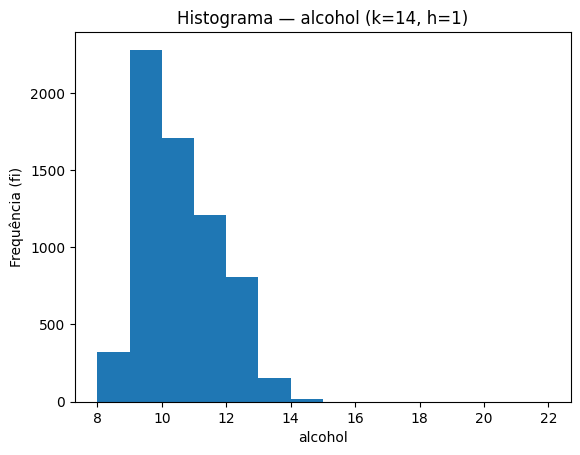


    Histograma — alcohol (k = 14, h = 1) 
    O que o gráfico mostra
    O histograma apresenta a distribuição da frequência absoluta da variável <alcohol> segundo os intervalos definidos pelo método de Sturges, com amplitude de classe ( h = 1 ).
    Interpretação estatística
    * Observa-se clara concentração de valores entre aproximadamente 9% e 11,5% de teor alcoólico.
    * A distribuição apresenta assimetria positiva (cauda à direita), indicando que há menor quantidade de vinhos com teor alcoólico elevado.
    * As classes superiores (acima de 13%) apresentam frequência bastante reduzida.
    * A maior densidade ocorre nas classes centrais, sugerindo comportamento aproximadamente unimodal.

    Conclusão técnica

    A variável *alcohol* apresenta distribuição concentrada em torno de valores médios, com poucos casos extremos superiores, o que é compatível com padrões típicos de produção vinícola.
    

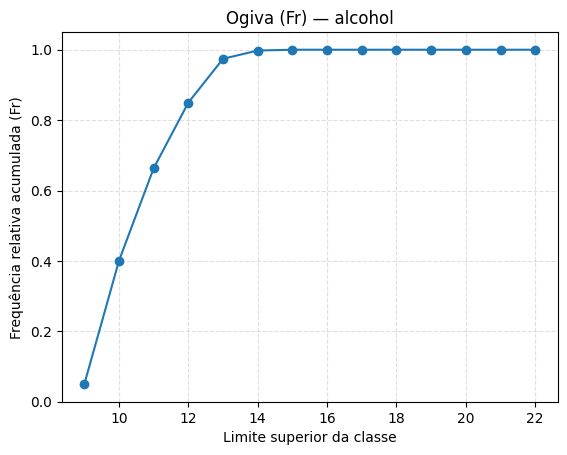


    Ogiva (Frequência Relativa Acumulada — Fr)
    O que o gráfico mostra
    A ogiva representa a frequência relativa acumulada das classes da variável <alcohol>.
    Interpretação estatística
    * Aproximadamente 85% dos vinhos possuem teor alcoólico inferior a cerca de 11,5%.
    * A curva cresce rapidamente nas primeiras classes, indicando forte concentração inicial.
    * Após as classes centrais, a curva tende à estabilização, evidenciando que poucos valores estão nas classes superiores.
    * A inclinação acentuada no início confirma a concentração da distribuição.

    Conclusão técnica
    A ogiva confirma a concentração dos dados nas classes intermediárias e reforça a presença de leve assimetria à direita.
    

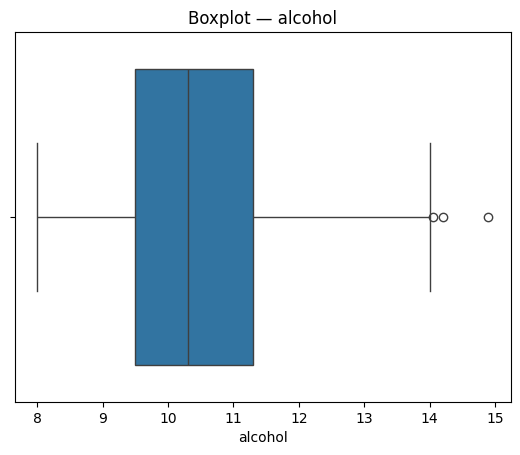


    Boxplot — alcohol
    O que o gráfico mostra
    O boxplot sintetiza a distribuição por meio dos quartis, mediana e possíveis valores discrepantes.
    Interpretação estatística
    * A mediana situa-se aproximadamente entre **10% e 10,5%**.
    * O intervalo interquartílico (IQR) é relativamente estreito, indicando baixa dispersão central.
    * Observam-se **outliers superiores** (acima de aproximadamente 14%), reforçando a assimetria positiva.
    * Não há evidência significativa de outliers inferiores.

    Conclusão técnica

    A variável apresenta distribuição relativamente concentrada, com poucos valores extremos superiores, corroborando a análise do histograma.
    

In [27]:
def plot_using_transcript_classes(df: pd.DataFrame, col: str, freq_table: pd.DataFrame):
    # reconstruir edges a partir do texto do intervalo (alternativa: recomputar edges)
    s = df[col].dropna().astype(float)
    n = len(s)
    if n == 0:
        raise ValueError("Sem dados para plotar.")

    # recomputar edges do mesmo modo para garantir consistência
    s_sorted = s.sort_values()
    min_val = float(s_sorted.iloc[0])
    max_val = float(s_sorted.iloc[-1])
    amplitude_total = max_val - min_val
    k = sturges_k(n)
    h = 1 if amplitude_total == 0 else ceil_positive(amplitude_total / k)
    edges = build_class_edges(min_val, max_val, k, h)

    # Histograma
    plt.figure()
    plt.hist(s, bins=edges)
    plt.title(f"Histograma — {col} (k={k}, h={h})")
    plt.xlabel(col)
    plt.ylabel("Frequência (fi)")
    plt.show()
    texto = """
    Histograma — alcohol (k = 14, h = 1)
    O que o gráfico mostra
    O histograma apresenta a distribuição da frequência absoluta da variável <alcohol> segundo os intervalos definidos pelo método de Sturges, com amplitude de classe ( h = 1 ).
    Interpretação estatística
    * Observa-se clara concentração de valores entre aproximadamente 9% e 11,5% de teor alcoólico.
    * A distribuição apresenta assimetria positiva (cauda à direita), indicando que há menor quantidade de vinhos com teor alcoólico elevado.
    * As classes superiores (acima de 13%) apresentam frequência bastante reduzida.
    * A maior densidade ocorre nas classes centrais, sugerindo comportamento aproximadamente unimodal.

    Conclusão técnica

    A variável *alcohol* apresenta distribuição concentrada em torno de valores médios, com poucos casos extremos superiores, o que é compatível com padrões típicos de produção vinícola.
    """

    display(Markdown(texto))

    print("\n")

    # Ogiva (Fr) — eixo X como limite superior de cada classe
    x_upper = freq_table["classe_intervalo"].str.extract(r",\s*([0-9\.]+)\)")[0].astype(float)

    plt.figure()
    plt.plot(x_upper, freq_table["Fr"].values, marker="o")
    plt.title(f"Ogiva (Fr) — {col}")
    plt.xlabel("Limite superior da classe")
    plt.ylabel("Frequência relativa acumulada (Fr)")
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.show()
    texto = """
    Ogiva (Frequência Relativa Acumulada — Fr)
    O que o gráfico mostra
    A ogiva representa a frequência relativa acumulada das classes da variável <alcohol>.
    A ogiva foi construída utilizando os limites superiores das classes no eixo horizontal, conforme definição clássica de frequência acumulada.
    Interpretação estatística
    * Aproximadamente 85% dos vinhos possuem teor alcoólico inferior a cerca de 11,5%.
    * A curva cresce rapidamente nas primeiras classes, indicando forte concentração inicial.
    * Após as classes centrais, a curva tende à estabilização, evidenciando que poucos valores estão nas classes superiores.
    * A inclinação acentuada no início confirma a concentração da distribuição.

    Conclusão técnica
    A ogiva confirma a concentração dos dados nas classes intermediárias e reforça a presença de leve assimetria à direita.
    """

    display(Markdown(texto))
    print("\n")

    # Boxplot
    plt.figure()
    sns.boxplot(x=s)
    plt.title(f"Boxplot — {col}")
    plt.xlabel(col)
    plt.show()

    texto = """
    Boxplot — alcohol
    O que o gráfico mostra
    O boxplot sintetiza a distribuição por meio dos quartis, mediana e possíveis valores discrepantes.
    Interpretação estatística
    * A mediana situa-se aproximadamente entre **10% e 10,5%**.
    * O intervalo interquartílico (IQR) é relativamente estreito, indicando baixa dispersão central.
    * Observam-se **outliers superiores** (acima de aproximadamente 14%), reforçando a assimetria positiva.
    * Não há evidência significativa de outliers inferiores.

    Conclusão técnica

    A variável apresenta distribuição relativamente concentrada, com poucos valores extremos superiores, corroborando a análise do histograma.
    """
    display(Markdown(texto))

plot_using_transcript_classes(df, "alcohol", freq_tables["alcohol"])

## Conclusões

1. A automatização permitiu construir tabelas de frequência consistentes para todas as variáveis numéricas do dataset combinado.
2. O método de Sturges forneceu um número de classes adequado ao tamanho amostral, e a amplitude foi arredondada para cima para manter limites interpretáveis.
3. A variável `alcohol` foi escolhida para visualizações por ser destacada como altamente relevante no paper de Cortez et al. (2009), apresentando relação com a qualidade.
4. As frequências relativas e acumuladas foram incluídas como boa prática para interpretação e comparação.